In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
president_county = pd.read_csv("4-US_Election_2020/president_county.csv")
president_cand = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")

senator_county = pd.read_csv("4-US_Election_2020/senate_county.csv")
senator_cand = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

governor_county = pd.read_csv("4-US_Election_2020/governors_county.csv")
governor_cand = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

In [14]:
president_merged = pd.merge(president_cand, president_county, on = ["state", "county"], how = "left")
senator_merged = pd.merge(senator_cand, senator_county, on = ["state", "county"], how = "left")
governor_merged = pd.merge(governor_cand, governor_county, on = ["state", "county"], how = "left")

In [15]:
def clean_election(df):
    df["state"] = df["state"].str.strip()
    df["county"] = df["county"].str.strip()
    df["party"] = df["party"].str.strip()

    df["party"] = df["party"].replace({"DEM": "DEMOCRAT", "REP": "REPUBLICAN"})
    df = df.query("party == 'DEMOCRAT' or party == 'REPUBLICAN'")

    df = df.rename(columns = {'total_votes_x': 'candidate_votes', 'current_votes': 'county_total'})
    return df[["state", "county", "party", "candidate_votes", "county_total"]]

In [16]:
president_clean = clean_election(president_merged)

print(f"Number of rows found: {len(president_clean)}")
display(president_clean.head())

Number of rows found: 9266


,state,county,party,candidate_votes,county_total
0,Delaware,Kent County,DEMOCRAT,44552,87025
1,Delaware,Kent County,REPUBLICAN,41009,87025
4,Delaware,New Castle County,DEMOCRAT,195034,287633
5,Delaware,New Castle County,REPUBLICAN,88364,287633
8,Delaware,Sussex County,REPUBLICAN,71230,129352


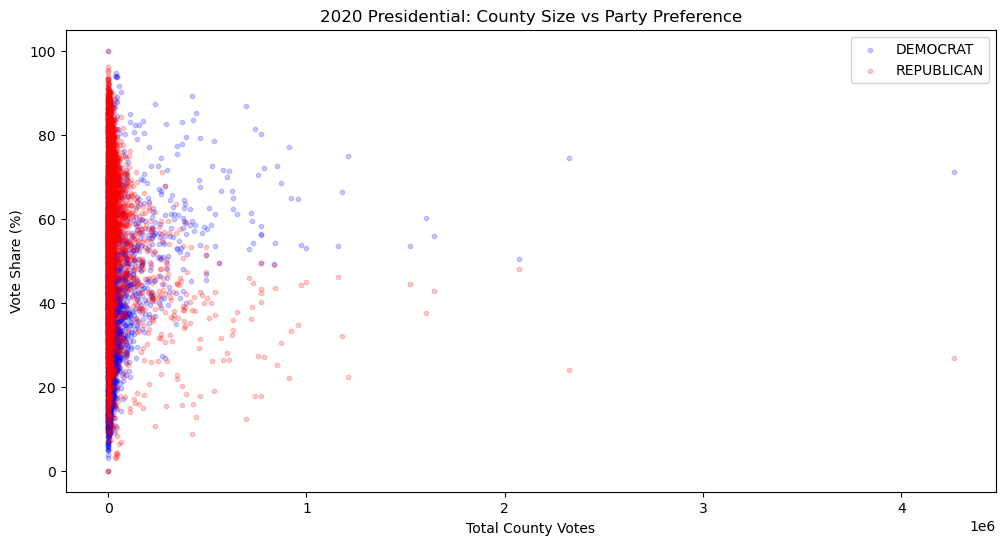

In [27]:
def plot_urban_rural(df, title):
    df['vote_share'] = (df['candidate_votes'] / df['county_total']) * 100
    
    plt.figure(figsize = (12, 6))
    for party, color in [('DEMOCRAT', 'blue'), ('REPUBLICAN', 'red')]:
        subset = df[df['party'] == party]
        plt.scatter(subset['county_total'], subset['vote_share'], 
                    color = color, alpha = 0.2, label = party, s = 10)
        
    plt.title(title)
    plt.xlabel("Total County Votes")
    plt.ylabel("Vote Share (%)")
    plt.legend()
    plt.show()

# Visualize the result
plot_urban_rural(president_clean, "2020 Presidential: County Size vs Party Preference")


/var/folders/jl/qqhlpvy11w1cfw6q5t0ly1zr0000gn/T/ipykernel_59714/232407154.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  president_graph = president_clean.groupby(["county_size", "party"]).agg(


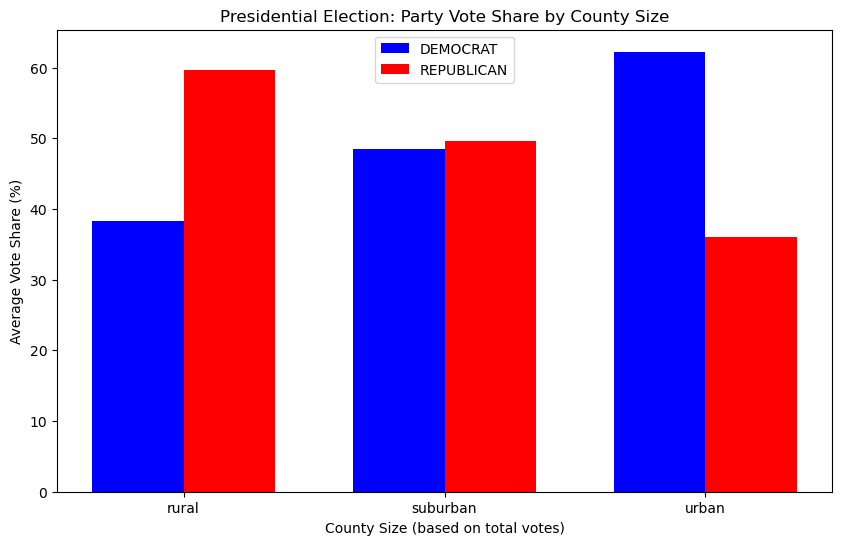

In [ ]:
county_bins   = [0, 50000,1000000, np.inf]
county_labels = ["rural", "suburban", "urban"]

president_clean["county_size"] = pd.cut(president_clean["county_total"],
                            bins=county_bins,
                            labels=county_labels)


president_graph = president_clean.groupby(["county_size", "party"]).agg(
    avg_vote_share=("vote_share", "mean")
).reset_index()


def plot_bar(df, title):
    plt.figure(figsize=(10,6))
    sizes = df["county_size"].unique()
    dem = df[df["party"] == "DEMOCRAT"]["avg_vote_share"]
    rep = df[df["party"] == "REPUBLICAN"]["avg_vote_share"]
    x = np.arange(len(sizes))
    width = 0.35
    
    plt.bar(x - width/2, dem, width, label="DEMOCRAT", color="blue")
    plt.bar(x + width/2, rep, width, label="REPUBLICAN", color="red")
    
    plt.xticks(x, sizes)
    plt.ylabel("Average Vote Share (%)")
    plt.xlabel("County Size (based on total votes)")
    plt.title(title)
    plt.legend()
    
    plt.show()


plot_bar(
    president_graph,
    "Presidential Election: Party Vote Share by County Size"
)



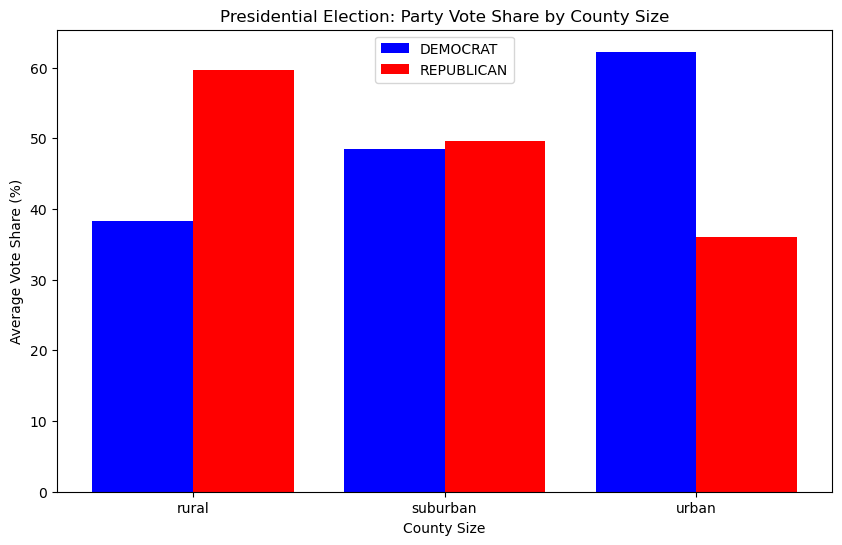

In [60]:
def plot_bar_simple(df, title):
    plt.figure(figsize=(10,6))
    
    sizes = ["rural", "suburban", "urban"]
    
    dem_vals = []
    rep_vals = []
    
    for size in sizes:
        dem = df[(df["county_size"] == size) & (df["party"] == "DEMOCRAT")]
        rep = df[(df["county_size"] == size) & (df["party"] == "REPUBLICAN")]
        
        dem_vals.append(dem["avg_vote_share"].values[0])
        rep_vals.append(rep["avg_vote_share"].values[0])
    
    x = [0, 1, 2]

    plt.bar(x, dem_vals, width=0.4, label="DEMOCRAT", color="blue")
    plt.bar([0.4, 1.4, 2.4], rep_vals, width=0.4, label="REPUBLICAN", color="red")

    plt.xticks([0.2, 1.2, 2.2], sizes)
    
    plt.xlabel("County Size")
    plt.ylabel("Average Vote Share (%)")
    plt.title(title)
    plt.legend()
    
    plt.show()
plot_bar_simple(
    president_graph,
    "Presidential Election: Party Vote Share by County Size"
)